<a href="https://colab.research.google.com/github/h186487/DAT158MLSopp/blob/main/notebooks/02_modeling_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clone
Henter først repoet inn i Colab-sesjonen.
Går så inn i mappen og henter siste endringer.

In [1]:
import os
if os.path.basename(os.getcwd()) != "DAT158MLSopp":
  if not os.path.exists("DAT158MLSopp"):
    !git clone https://github.com/h186487/DAT158MLSopp.git
  %cd DAT158MLSopp
!git pull
!pip install -q ucimlrepo

Cloning into 'DAT158MLSopp'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 109 (delta 36), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 1.77 MiB | 4.01 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/DAT158MLSopp
Already up to date.


Felles hjelpefunksjoner:

In [2]:
%%writefile src/modeling_utils.py
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, accuracy_score, confusion_matrix

SEED = 42

def make_pipeline(model, columns):
    """Pipeline: one-hot-koding av de oppgitte kolonnene + modell."""
    pre = ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), list(columns))]
    )
    return Pipeline([("pre", pre), ("model", model)])


def mask_unknown(X, p, seed=SEED):
    """Erstatter hver verdi med 'unknown' med sannsynlighet p ('Vet ikke')."""
    rng = np.random.default_rng(seed)
    return X.mask(rng.random(X.shape) < p, "unknown")


def corrupt(X, p, seed=SEED):
    """Erstatter hver verdi med en TILFELDIG ANNEN verdi fra samme kolonne
    med sannsynlighet p (brukeren svarer feil)."""
    rng = np.random.default_rng(seed)
    Xn = X.copy()
    for col in X.columns:
        values = X[col].unique()
        hit = rng.random(len(X)) < p
        Xn.loc[hit, col] = rng.choice(values, hit.sum())
    return Xn


def augment(X, y, ps=(0.2, 0.4), seed=SEED):
    """Originale data + maskerte kopier. KUN for treningsdata."""
    Xs, ys = [X], [y]
    for i, p in enumerate(ps):
        Xs.append(mask_unknown(X, p, seed + i + 1))
        ys.append(y)
    return pd.concat(Xs, ignore_index=True), pd.concat(ys, ignore_index=True)


def cv_evaluate(make_model, X, y, n_splits=5, n_repeats=1,
                augment_train=False, seed=SEED):
    """Stratifisert (repetert) CV. Returnerer én rad per fold.
    Augmentering skjer INNE i hver fold, kun på treningsdelen."""
    rows = []
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for tr, va in skf.split(X, y):
            Xtr, ytr = X.iloc[tr], y.iloc[tr]
            Xva, yva = X.iloc[va], y.iloc[va]
            if augment_train:
                Xtr, ytr = augment(Xtr, ytr)
            pred = make_model().fit(Xtr, ytr).predict(Xva)
            tn, fp, fn, tp = confusion_matrix(yva, pred, labels=[0, 1]).ravel()
            rows.append({
                "recall": recall_score(yva, pred, zero_division=0),
                "precision": precision_score(yva, pred, zero_division=0),
                "accuracy": accuracy_score(yva, pred),
                "fn": fn, "fp": fp,
            })
    return pd.DataFrame(rows)


def pm(df, col, digits=4):
    """Formater 'snitt ± std' for tabeller."""
    return f"{df[col].mean():.{digits}f} ± {df[col].std():.{digits}f}"


def oof_proba(make_model, X, y, val_mask_ps=(0,), augment_train=False,
              n_splits=5, seed=SEED):
    """Out-of-fold sannsynligheter på treningsdata. Hver rad får en
    prediksjon fra en modell som ALDRI har sett raden.
    val_mask_ps: valideringsradene maskeres også (0 = uendret)."""
    ps, ys = [], []
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for k, (tr, va) in enumerate(skf.split(X, y)):
        Xtr, ytr = X.iloc[tr], y.iloc[tr]
        if augment_train:
            Xtr, ytr = augment(Xtr, ytr)
        m = make_model().fit(Xtr, ytr)
        for j, q in enumerate(val_mask_ps):
            Xv = X.iloc[va] if q == 0 else mask_unknown(X.iloc[va], q, seed + 100 * k + j)
            ps.append(m.predict_proba(Xv)[:, 1])
            ys.append(y.iloc[va].to_numpy())
    return np.concatenate(ps), np.concatenate(ys)


def choose_thresholds(y, p, min_precision=0.99, cap_low=0.05):
    """T_LOW:  p <= T_LOW  -> 'ingen tegn på gift'
       T_HIGH: p >= T_HIGH -> 'sannsynlig giftig'. Mellom -> 'usikker'.
    Velges på validerings-sannsynligheter (aldri på test)."""
    y = np.asarray(y)
    grid = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5,
            0.7, 0.9, 0.95, 0.99]
    # T_LOW: høyeste terskel der INGEN giftige havner under den, med halv margin
    ok = [t for t in grid if (p[y == 1] >= t).all()]
    t_low = min((max(ok) if ok else grid[0]) / 2, cap_low)
    # T_HIGH: laveste terskel der precision for 'giftig' er høy nok
    t_high = 0.99
    for t in grid:
        sel = p >= t
        if sel.sum() > 0 and (y[sel] == 1).mean() >= min_precision:
            t_high = t
            break
    return float(t_low), float(t_high)

Overwriting src/modeling_utils.py


Import og last data:

In [3]:
import time, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

from src.modeling_utils import *
from src.metrics import report

os.makedirs("report/figures", exist_ok=True)
os.makedirs("report/tables", exist_ok=True)

train = pd.read_csv("data/processed/train.csv")
test = pd.read_csv("data/processed/test.csv")
Xtr, ytr = train.drop(columns="poisonous"), train["poisonous"]
Xte, yte = test.drop(columns="poisonous"), test["poisonous"]
cols = list(Xtr.columns)
print(Xtr.shape, Xte.shape, ytr.mean().round(3))

(6499, 21) (1625, 21) 0.482


# Modellsammenligning
4 modelltyper og hvilken som fanger flest giftige sopper:


1.   Logistic Regression: en lineær modell.
2.   Decision Tree: et tre av ja/nei-spørsmål. Vi tester både et grunt tre (`max_depth=3`) og et uten grense. Det ubegrensede treet er et eksempel på overfitting-risiko.
3. Random Forest: mange tilfeldige trær som stemmer sammen.
4. Gradient Boosting: trær bygget etter hverandre, hvert nytt tre retter opp feilene til de forrige.

5-fold kryssvalidering, gjentatt 3 ganger. Treningsdataene (6499 sopper) deles i 5 deler. Modellen trenes på 4 deler og testes på den femte, fem ganger. Dette gjøres 3 ganger med ulik tilfeldig deling. Vi får 15 målinger per modell, og vi kan finne snitt +/- standardavvik. Testsettet (1625 sopper) røres ikke.



Definer modellene:

In [4]:
print(len(cols), "features")

def make_rf(**params):
    return make_pipeline(RandomForestClassifier(random_state=SEED, n_jobs=-1, **params), cols)

models = {
    "Logistic Regression": lambda: make_pipeline(LogisticRegression(max_iter=1000), cols),
    "Decision Tree (depth=3)": lambda: make_pipeline(DecisionTreeClassifier(max_depth=3, random_state=SEED), cols),
    "Decision Tree (ubegrenset)": lambda: make_pipeline(DecisionTreeClassifier(random_state=SEED), cols),
    "Random Forest": lambda: make_rf(n_estimators=100),
    "Gradient Boosting": lambda: make_pipeline(GradientBoostingClassifier(random_state=SEED), cols),
}
print("Modeller klare:", list(models))

21 features
Modeller klare: ['Logistic Regression', 'Decision Tree (depth=3)', 'Decision Tree (ubegrenset)', 'Random Forest', 'Gradient Boosting']


Sammenligningen:

In [5]:
rows = []
for name, mk in models.items():
    t0 = time.time()
    df = cv_evaluate(mk, Xtr, ytr, n_splits=5, n_repeats=3)   # 15 treninger
    sec = (time.time() - t0) / len(df)
    rows.append({
        "Modell": name,
        "Recall (giftig)": pm(df, "recall"),
        "Precision": pm(df, "precision"),
        "Accuracy": pm(df, "accuracy"),
        "FN per fold": f"{df['fn'].mean():.2f}",
        "Tid per fit (s)": f"{sec:.2f}",
    })
    print("ferdig:", name)

compare = pd.DataFrame(rows)
compare.to_csv("report/tables/B_modellsammenligning.csv", index=False)
compare

ferdig: Logistic Regression
ferdig: Decision Tree (depth=3)
ferdig: Decision Tree (ubegrenset)
ferdig: Random Forest
ferdig: Gradient Boosting


,Modell,Recall (giftig),Precision,Accuracy,FN per fold,Tid per fit (s)
0,Logistic Regression,0.9993 ± 0.0018,1.0000 ± 0.0000,0.9996 ± 0.0009,0.47,0.15
1,Decision Tree (depth=3),0.9980 ± 0.0020,0.9733 ± 0.0052,0.9858 ± 0.0029,1.27,0.25
2,Decision Tree (ubegrenset),0.9995 ± 0.0012,1.0000 ± 0.0000,0.9997 ± 0.0006,0.33,0.20
3,Random Forest,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.00,1.18
4,Gradient Boosting,0.9994 ± 0.0012,1.0000 ± 0.0000,0.9997 ± 0.0006,0.40,0.90


# Random Forest
Tren modellen og lagre den:

In [6]:
os.makedirs("models", exist_ok=True)

Xa, ya = augment(Xtr, ytr)
print("Før maskering:", Xtr.shape, " Etter:", Xa.shape)

model_v1 = make_rf(n_estimators=100).fit(Xa, ya)

joblib.dump(model_v1, "models/model.joblib")
json.dump({"T_LOW": 0.05, "T_HIGH": 0.95}, open("models/config.json", "w"))
print("Lagret!")

Før maskering: (6499, 21)  Etter: (19497, 21)
Lagret!


Røyktest (sjekket at modellen kan lastes inn og gir fornuftige svar):

In [7]:
m = joblib.load("models/model.joblib")

print(m.predict_proba(Xte.head(3)))
print("Fasit:", yte.head(3).tolist())

allunk = pd.DataFrame([{c: "unknown" for c in cols}])
print("Alt ukjent -> sannsynlighet for giftig:", m.predict_proba(allunk)[0, 1])

!ls -lh models/

[[0. 1.]
 [0. 1.]
 [1. 0.]]
Fasit: [1, 1, 0]
Alt ukjent -> sannsynlighet for giftig: 0.49
total 8.6M
-rw-r--r-- 1 root root   31 Oct 10 17:16 config.json
-rw-r--r-- 1 root root 8.6M Oct 10 17:16 model.joblib
-rw-r--r-- 1 root root    1 Oct 10 17:15 temp


Grid Search:

In [8]:
grid = GridSearchCV(
    make_rf(),
    param_grid={
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 5, None],
    },
    scoring={"recall": "recall", "accuracy": "accuracy"},
    refit="recall",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
)
grid.fit(Xtr, ytr)
print("Ferdig!")

Ferdig!


Vis resultatene:

In [9]:
res = (pd.DataFrame(grid.cv_results_)
       [["param_model__n_estimators", "param_model__max_depth",
         "mean_test_recall", "std_test_recall", "mean_test_accuracy"]]
       .sort_values(["mean_test_recall", "mean_test_accuracy"], ascending=False)
       .reset_index(drop=True))
res.columns = ["n_estimators", "max_depth", "Recall (snitt)", "Recall (std)", "Accuracy (snitt)"]
res.to_csv("report/tables/B_gridsearch.csv", index=False)
res

,n_estimators,max_depth,Recall (snitt),Recall (std),Accuracy (snitt)
0,50,None,1.000000,0.000000,1.000000
1,100,None,1.000000,0.000000,1.000000
2,200,None,1.000000,0.000000,1.000000
3,50,5,0.978939,0.007432,0.989845
4,100,5,0.978939,0.007432,0.989845
5,200,5,0.978939,0.007432,0.989845
6,100,3,0.968729,0.018608,0.984922
7,200,3,0.934579,0.027033,0.968459
8,50,3,0.925317,0.014502,0.963995


In [10]:
BEST = {"n_estimators": 50, "max_depth": None}
print("Valgt:", BEST)

Valgt: {'n_estimators': 50, 'max_depth': None}


Learning curve:

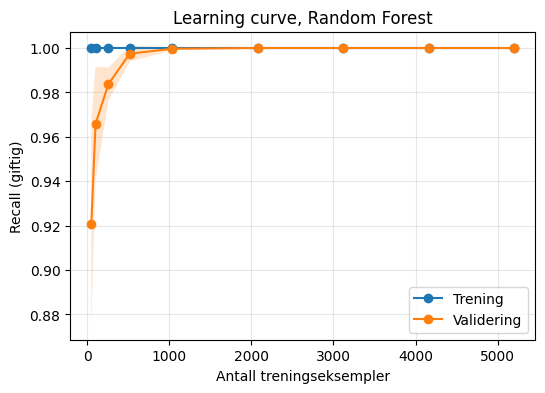

In [11]:
sizes, tr_s, va_s = learning_curve(
    make_rf(**BEST), Xtr, ytr,
    scoring="recall", shuffle=True, random_state=SEED,
    train_sizes=[0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1)

plt.figure(figsize=(6, 4))
for s, lab in [(tr_s, "Trening"), (va_s, "Validering")]:
    plt.plot(sizes, s.mean(1), marker="o", label=lab)
    plt.fill_between(sizes, s.mean(1) - s.std(1), s.mean(1) + s.std(1), alpha=0.2)
plt.xlabel("Antall treningseksempler")
plt.ylabel("Recall (giftig)")
plt.title("Learning curve, Random Forest")
plt.legend()
plt.grid(alpha=.3)
plt.savefig("report/figures/B_learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()